# Mega Case Study

## Part 1 - SOM

### Importing the libraries

In [14]:
!pip install minisom

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Importing the dataset

In [16]:
dataset = pd.read_csv('Credit_Card_Applications.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

### Feature Scaling

In [17]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
X = sc.fit_transform(X)

### Training the SOM

In [18]:
from minisom import MiniSom
som = MiniSom(x=10, y=10, input_len= 15, sigma= 1.0, learning_rate = 0.5)
som.random_weights_init(X)
som.train_random(data = X, num_iteration = 100)

### Visualizing the results

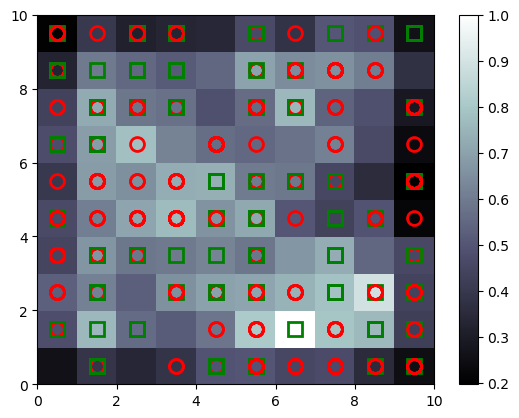

In [19]:
from pylab import bone, pcolor, colorbar, plot, show
bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['o', 's']
colors = ['r', 'g']
for i, x in enumerate(X):
    w = som.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor = colors[y[i]],
         markerfacecolor = 'None',
         markersize = 10,
         markeredgewidth = 2)
show()

### Finding the frauds

In [20]:
mappings = som.win_map(X)
frauds = np.concatenate((mappings[(2,5)], mappings[(6,4)]), axis = 0)
frauds = sc.inverse_transform(frauds)

### Printing the fraudulent clients

In [21]:
print('Fraud Customer IDs')
for i in frauds[:, 0]:
  print(int(i))

Fraud Customer IDs
15642063
15656417
15665181


## Part 2 - Going from Unsupervised to Supervised Deep Learning

### Creating the Matrix of Features

In [22]:
customers = dataset.iloc[:, 1:].values

### Creating the Dependent Variable

In [23]:
is_fraud = np.zeros(len(dataset))
for i in range(len(dataset)):
  if dataset.iloc[i,0] in frauds:
    is_fraud[i] = 1

## Part 3 - ANN

### Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
customers = sc.fit_transform(customers)

### Building the ANN

In [25]:
import tensorflow as tf
tf.__version__

'2.21.0'

In [26]:
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=2, activation='relu'))
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

### Training the ANN

In [27]:
ann.fit(customers, is_fraud, batch_size = 1, epochs = 10)

Epoch 1/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - accuracy: 0.7986 - loss: 0.5636
Epoch 2/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 753us/step - accuracy: 0.9681 - loss: 0.2601
Epoch 3/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9928 - loss: 0.1552
Epoch 4/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 989us/step - accuracy: 0.9942 - loss: 0.1002
Epoch 5/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 934us/step - accuracy: 0.9957 - loss: 0.0675
Epoch 6/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9957 - loss: 0.0478
Epoch 7/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step - accuracy: 0.9957 - loss: 0.0340
Epoch 8/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - accuracy: 0.9957 - loss: 0.0258
Epoch 9/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step - accuracy: 0.9957 - loss: 0.0225
Epoch 10/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step - accuracy: 0.9957 - loss: 0.0206


### Predicting the test set results

In [ ]:
y_pred = ann.predict(customers)
y_pred = np.concatenate((dataset.iloc[:, 0:1],y_pred),axis=1)
y_pred = y_pred[y_pred[:, 1].argsort()]

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [29]:
print(y_pred)

[[1.57574340e+07 3.61227492e-08]
 [1.56739070e+07 4.25986570e-08]
 [1.56058720e+07 1.10814980e-07]
 ...
 [1.55995350e+07 1.04169019e-01]
 [1.56877650e+07 1.11640573e-01]
 [1.56564170e+07 1.34412140e-01]]
